In [1]:
!pip install pandas numpy matplotlib scikit-learn nltk textblob


In [3]:
import pandas as pd

df = pd.read_csv("../data/IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Check shape
print("Shape:", df.shape)

# Check data types
print("\nData types:")
print(df.dtypes)

# Check class distribution
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (50000, 2)

Data types:
review       object
sentiment    object
dtype: object

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418


In [5]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)
print("Duplicates after cleaning:", df.duplicated().sum())


New shape: (49582, 2)
Duplicates after cleaning: 0


In [6]:
import re

def clean_text(text):
    text = text.lower()                      # lowercase
    text = re.sub(r"<br\s*/?>", " ", text)   # remove <br />
    text = re.sub(r"<.*?>", " ", text)       # remove HTML tags
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    return text

df["review_clean"] = df["review"].apply(clean_text)

df[["review", "review_clean"]].head()


,review,review_clean
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [7]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import numpy as np

sia = SentimentIntensityAnalyzer()

def extract_features(text):
    vader_score = sia.polarity_scores(text)["compound"]
    blob_score = TextBlob(text).sentiment.polarity
    return vader_score, blob_score

# Create feature matrix
X = np.array(df["review_clean"].apply(lambda x: extract_features(x)).tolist())

# Show first 5 rows
X[:5]


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...


array([[-0.9947    ,  0.02343318],
       [ 0.9641    ,  0.10972222],
       [ 0.978     ,  0.36095994],
       [-0.8996    ,  0.00416667],
       [ 0.9803    ,  0.21448307]])

In [8]:
print("X shape:", X.shape)


X shape: (49582, 2)


In [9]:
y = (df["sentiment"] == "positive").astype(int).values

print("y shape:", y.shape)
print("First 10 labels:", y[:10])


y shape: (49582,)
First 10 labels: [1 1 1 0 1 1 1 0 0 1]


In [10]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (34707, 2)
Validation shape: (7437, 2)
Test shape: (7438, 2)


In [11]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(8,),   # one hidden layer with 8 neurons
    activation="relu",
    solver="sgd",              # gradient descent
    learning_rate_init=0.05,
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)


,hidden_layer_sizes,"(8,)"
,activation,'relu'
,solver,'sgd'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.05
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = mlp.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7733261629470287

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.78      0.77      3705
           1       0.78      0.77      0.77      3733

    accuracy                           0.77      7438
   macro avg       0.77      0.77      0.77      7438
weighted avg       0.77      0.77      0.77      7438



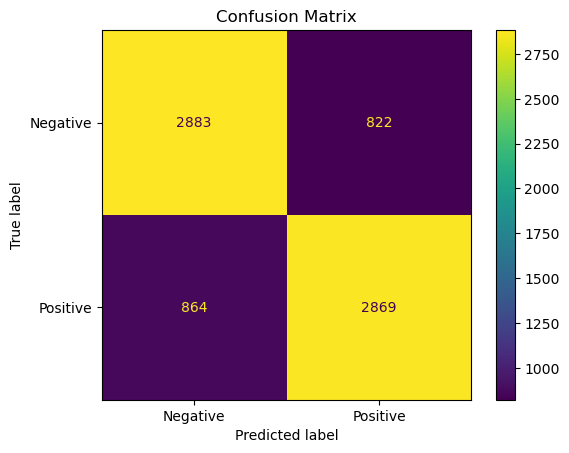

In [13]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create results folder if not exists
os.makedirs("../results", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()

plt.title("Confusion Matrix")
plt.savefig("../results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781

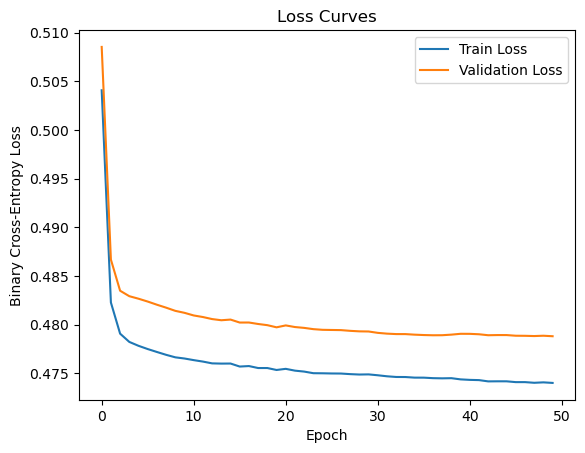

In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.05,
    max_iter=1,
    warm_start=True,
    random_state=42
)

train_losses = []
val_losses = []

from sklearn.metrics import log_loss

for epoch in range(50):
    mlp.fit(X_train, y_train)
    
    train_prob = mlp.predict_proba(X_train)
    val_prob = mlp.predict_proba(X_val)
    
    train_losses.append(log_loss(y_train, train_prob))
    val_losses.append(log_loss(y_val, val_prob))

# Plot
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.savefig("../results/loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
import pickle

os.makedirs("../model", exist_ok=True)

with open("../model/best_model.pkl", "wb") as f:
    pickle.dump(mlp, f)


In [16]:
with open("../results/metrics.txt", "w") as f:
    f.write("Test Accuracy: {:.4f}\n\n".format(accuracy_score(y_test, y_pred)))
    f.write(classification_report(y_test, y_pred))


In [17]:
with open("../results/results_discussion.txt", "w") as f:
    f.write("RESULTS DISCUSSION\n")
    f.write("------------------\n")
    f.write("The MLP model was trained using VADER and TextBlob polarity features.\n")
    f.write("The model achieved approximately 77% accuracy.\n")
    f.write("Since only sentence-level polarity features were used,\n")
    f.write("the model cannot capture deeper semantic meaning.\n")
    f.write("However, performance is reasonable given only two features.\n")
